In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install monai nibabel SimpleITK scikit-image albumentations -q
import torch, numpy as np, matplotlib.pyplot as plt
print("GPU available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.5 MB/s eta 0:00:0000:010:01
GPU available: True


In [3]:
!pip install monai nibabel SimpleITK scikit-image albumentations thop -q
print("Installation complete!")

Installation complete!


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from thop import profile  # For GFLOPS and parameter count calculations

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


In [5]:
!git clone https://github.com/DIAGNijmegen/picai_labels.git /kaggle/working/picai_labels
print("Labels repository cloned successfully!")

Cloning into '/kaggle/working/picai_labels'...
remote: Enumerating objects: 10506, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 10506 (delta 57), reused 58 (delta 36), pack-reused 10417 (from 1)
Receiving objects: 100% (10506/10506), 32.80 MiB | 32.08 MiB/s, done.
Resolving deltas: 100% (6062/6062), done.
Labels repository cloned successfully!


In [7]:
!pip install monai nibabel SimpleITK scikit-image albumentations thop -q
print("Installation complete!")

Installation complete!


In [6]:
import os
import glob
from sklearn.model_selection import train_test_split
import pandas as pd
import SimpleITK as sitk
import numpy as np
from skimage.transform import resize

# 1. Locate images root from the attached dataset
dataset_root = '/kaggle/input/datasets/varshithpsingh/prostate-cancer-pi-cai-dataset'
images_root = dataset_root  # Folds 0-4 are directly here

# 2. Locate metadata/marksheet (using the available metadata file)
marksheet_path = os.path.join(dataset_root, 'Metadata with lesion info.csv')

# 3. Use the cloned labels directory for whole gland masks
mask_dir = '/kaggle/working/picai_labels/anatomical_delineations/whole_gland/AI/Bosma22b'

print("Using marksheet:", marksheet_path)
print("Using mask directory:", mask_dir)

# Read metadata and adapt columns to match your pipeline
marksheet = pd.read_csv(marksheet_path)
# Note: Check your CSV column names if patient_id/study_id differ, but usually they map as follows:
if 'patient_id' not in marksheet.columns and 'patient_id_' in marksheet.columns: # fallback check
    marksheet['patient_id'] = marksheet['patient_id_']
    
marksheet['case_id'] = marksheet['patient_id'].astype(str) + '_' + marksheet['study_id'].astype(str)

# Function to find the patient image path dynamically across folds 0-4
def find_image_path(row):
    patient_folder = str(row['patient_id'])
    case_id = row['case_id']
    # Search across all fold folders
    for fold in range(5):
        path = os.path.join(dataset_root, f'picai_public_images_fold{fold}', patient_folder, f'{case_id}_t2w.mha')
        if os.path.exists(path):
            return path
    return ""

marksheet['image_path'] = marksheet.apply(find_image_path, axis=1)
marksheet['mask_path'] = marksheet['case_id'].apply(lambda c: os.path.join(mask_dir, f"{c}.nii.gz"))

marksheet['image_exists'] = marksheet['image_path'].apply(lambda p: p != "" and os.path.exists(p))
marksheet['mask_exists'] = marksheet['mask_path'].apply(os.path.exists)

valid_df = marksheet[marksheet['image_exists'] & marksheet['mask_exists']].reset_index(drop=True)
print(f"Total valid cases found with both image and mask: {len(valid_df)}")

# Strict 60% Train, 20% Validation, 20% Test via random sampling as per instructions
train_val_df, test_df = train_test_split(valid_df, test_size=0.20, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42)

print(f"Cases -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

def load_and_slice(row, target_size=256):
    img = sitk.GetArrayFromImage(sitk.ReadImage(row['image_path']))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(row['mask_path']))
    slices = []
    for z in range(img.shape[0]):
        if mask[z].sum() > 0:  # Keep slices containing the prostate
            im = img[z].astype(np.float32)
            im = (im - im.mean()) / (im.std() + 1e-8)
            im_r = resize(im, (target_size, target_size), preserve_range=True)
            mk_r = resize(mask[z], (target_size, target_size), order=0, preserve_range=True, anti_aliasing=False)
            slices.append((im_r.astype(np.float32), mk_r.astype(np.uint8)))
    return slices

def build_slice_cache(df, cache_prefix):
    all_slices = []
    for _, row in df.iterrows():
        try:
            all_slices.extend(load_and_slice(row))
        except Exception:
            pass
    images = np.stack([s[0] for s in all_slices]).astype(np.float32)
    masks = np.stack([s[1] for s in all_slices]).astype(np.uint8)
    np.save(f'/kaggle/working/{cache_prefix}_images.npy', images)
    np.save(f'/kaggle/working/{cache_prefix}_masks.npy', masks)
    print(f"Saved {len(images)} slices for {cache_prefix}")
    return images, masks

# Caching arrays separately to avoid object-dtype bugs
train_imgs, train_masks = build_slice_cache(train_df, 'train')
val_imgs, val_masks = build_slice_cache(val_df, 'val')
test_imgs, test_masks = build_slice_cache(test_df, 'test')

Using marksheet: /kaggle/input/datasets/varshithpsingh/prostate-cancer-pi-cai-dataset/Metadata with lesion info.csv
Using mask directory: /kaggle/working/picai_labels/anatomical_delineations/whole_gland/AI/Bosma22b
Total valid cases found with both image and mask: 871
Cases -> Train: 522 | Val: 174 | Test: 175
Saved 7799 slices for train
Saved 2550 slices for val
Saved 2570 slices for test


In [2]:
import torch, torch.nn as nn, numpy as np, json, os
from torch.utils.data import Dataset, DataLoader
import albumentations as A

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reload cached slices — confirm they're still there first
for f in ['train_images.npy','train_masks.npy','val_images.npy','val_masks.npy','test_images.npy','test_masks.npy']:
    print(f, os.path.exists(f'/kaggle/working/{f}'))

train_images.npy True
train_masks.npy True
val_images.npy True
val_masks.npy True
test_images.npy True
test_masks.npy True


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import albumentations as A

class PICAIDataset(Dataset):
    def __init__(self, images_path, masks_path, augment=False):
        self.images = np.load(images_path)
        self.masks = np.load(masks_path)
        self.augment = augment
        # Data augmentation details: horizontal flips and rotation
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=15, p=0.5),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, mask = self.images[idx], self.masks[idx]
        if self.augment:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']
        return torch.tensor(img).unsqueeze(0).float(), torch.tensor(mask).long()

# Initialized with batch size 16 for dual T4 optimization
train_loader = DataLoader(PICAIDataset('/kaggle/working/train_images.npy', '/kaggle/working/train_masks.npy', augment=True),
                           batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(PICAIDataset('/kaggle/working/val_images.npy', '/kaggle/working/val_masks.npy', augment=False),
                           batch_size=16, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PICAIDataset('/kaggle/working/test_images.npy', '/kaggle/working/test_masks.npy', augment=False),
                           batch_size=16, num_workers=2, pin_memory=True)

print("DataLoaders ready with batch size 16!")

DataLoaders ready with batch size 16!


Old checkpoints cleared! Ready to train fresh from Epoch 1 with batch size 16.


In [3]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(self.relu(g1 + x1))
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_c=1, out_c=2, base=32):
        super().__init__()
        def cb(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True)
            )
        
        # 4 Encoder levels
        self.enc1 = cb(in_c, base)
        self.enc2 = cb(base, base*2)
        self.enc3 = cb(base*2, base*4)
        self.enc4 = cb(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck with Dropout
        self.bottleneck = nn.Sequential(cb(base*8, base*16), nn.Dropout2d(0.3))
        
        # 4 Decoder levels with Attention Gates
        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.att4 = AttentionBlock(F_g=base*8, F_l=base*8, F_int=base*4)
        self.dec4 = cb(base*16, base*8)
        
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.att3 = AttentionBlock(F_g=base*4, F_l=base*4, F_int=base*2)
        self.dec3 = cb(base*8, base*4)
        
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.att2 = AttentionBlock(F_g=base*2, F_l=base*2, F_int=base)
        self.dec2 = cb(base*4, base*2)
        
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.att1 = AttentionBlock(F_g=base, F_l=base, F_int=base//2)
        self.dec1 = cb(base*2, base)
        
        self.out = nn.Conv2d(base, out_c, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        
        d4 = self.up4(b)
        x4 = self.att4(d4, e4)
        d4 = torch.cat((x4, d4), dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        x3 = self.att3(d3, e3)
        d3 = torch.cat((x3, d3), dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        x2 = self.att2(d2, e2)
        d2 = torch.cat((x2, d2), dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        x1 = self.att1(d1, e1)
        d1 = torch.cat((x1, d1), dim=1)
        d1 = self.dec1(d1)
        
        return self.out(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionUNet().to(device)

if torch.cuda.device_count() > 1:
    print(f"🚀 Using {torch.cuda.device_count()} GPUs with DataParallel!")
    model = nn.DataParallel(model)
else:
    print("Attention U-Net initialized successfully on single GPU!")

🚀 Using 2 GPUs with DataParallel!


In [6]:
#Restore cell
import os
import json
import torch

# Paths to your saved files
ckpt_path = '/kaggle/working/best_model.pth'
history_path = '/kaggle/working/loss_history.json'

# Initialize or reset variables safely
train_losses, val_losses = [], []
start_epoch = 0
best_val_loss = float('inf')

# 1. Restore loss history (epochs completed, train/val loss curves)
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        hist = json.load(f)
        train_losses, val_losses = hist['train'], hist['val']
        start_epoch = len(train_losses)
        best_val_loss = min(val_losses) if val_losses else float('inf')
    print(f"✅ Loss history found! Resuming from Epoch {start_epoch + 1}.")
    print(f"   Best validation loss achieved so far: {best_val_loss:.4f}")
else:
    print("⚠️ No previous history file found. Starting fresh from Epoch 1.")

# 2. Restore best model weights
if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("✅ Successfully loaded best model weights from checkpoint.")
else:
    print("⚠️ No model checkpoint found. Using fresh model initialization.")

✅ Loss history found! Resuming from Epoch 54.
   Best validation loss achieved so far: 0.1387
✅ Successfully loaded best model weights from checkpoint.


In [5]:
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler

def dice_loss(pred, target, eps=1e-6):
    pred = torch.softmax(pred, dim=1)[:, 1]
    target = (target == 1).float()
    inter = (pred * target).sum((1, 2))
    return 1 - ((2 * inter + eps) / (pred.sum((1,2)) + target.sum((1,2)) + eps)).mean()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
ce_loss = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]).to(device))
scaler = GradScaler()

train_accs, val_accs = [], []  # NEW: per-epoch accuracy tracking
patience, patience_ctr = 10, 0
total_epochs = 60

print(f"🚀 Running training loop from epoch {start_epoch + 1} to {total_epochs}...")

for epoch in range(start_epoch, total_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(x)
            loss = dice_loss(outputs, y) + ce_loss(outputs, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.numel()
    train_acc = correct / total

    model.eval()
    val_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            with autocast():
                outputs = model(x)
                loss = dice_loss(outputs, y) + ce_loss(outputs, y)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            v_correct += (preds == y).sum().item()
            v_total += y.numel()
    val_acc = v_correct / v_total

    t_loss = train_loss / len(train_loader)
    v_loss = val_loss / len(val_loader)
    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{total_epochs} | Train Loss: {t_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {val_acc:.4f}")

    with open(history_path, 'w') as f:
        json.dump({'train': train_losses, 'val': val_losses, 'train_acc': train_accs, 'val_acc': val_accs}, f)

    if v_loss < best_val_loss:
        best_val_loss = v_loss; patience_ctr = 0
        torch.save(model.state_dict(), ckpt_path)
        print("   💾 Saved new best model checkpoint!")
    else:
        patience_ctr += 1
        if epoch >= 49 and patience_ctr >= patience:
            print(f"Minimum 50 epochs completed. Early stopping triggered at epoch {epoch+1}.")
            break

🚀 Running training loop from epoch 50 to 60...


/tmp/ipykernel_65725/377301893.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_65725/377301893.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_65725/377301893.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 50/60 | Train Loss: 0.1051 Acc: 0.9974 | Val Loss: 0.1404 Acc: 0.9969
Epoch 51/60 | Train Loss: 0.1039 Acc: 0.9974 | Val Loss: 0.1435 Acc: 0.9966
Epoch 52/60 | Train Loss: 0.1020 Acc: 0.9974 | Val Loss: 0.1387 Acc: 0.9967
   💾 Saved new best model checkpoint!
Epoch 53/60 | Train Loss: 0.0987 Acc: 0.9975 | Val Loss: 0.1469 Acc: 0.9969


KeyboardInterrupt: 

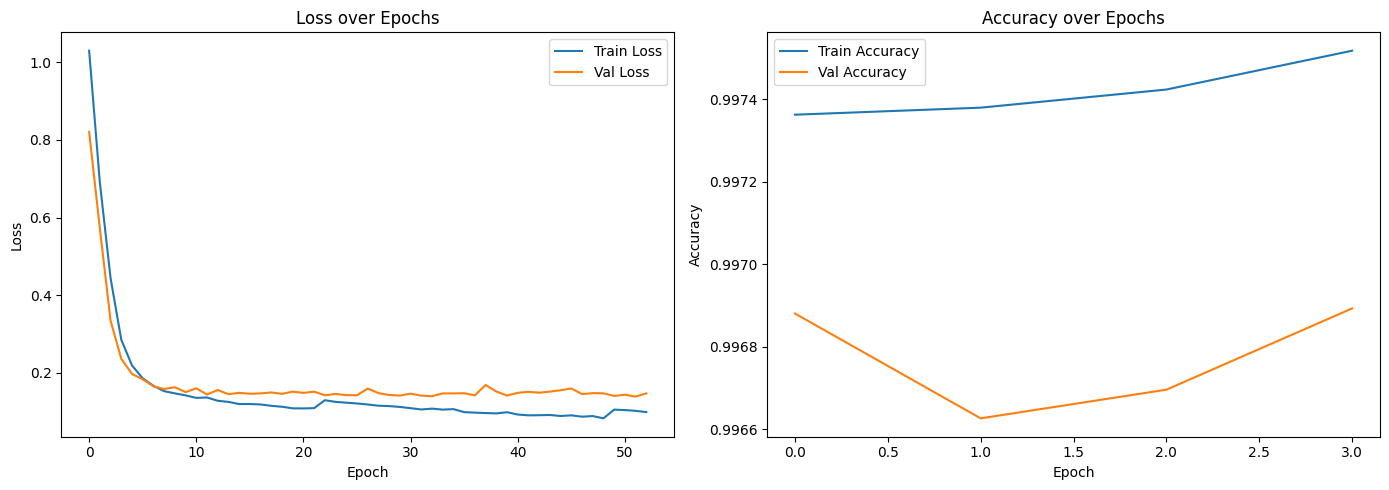

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss'); axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss over Epochs'); axes[0].legend()

axes[1].plot(train_accs, label='Train Accuracy'); axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy over Epochs'); axes[1].legend()
plt.tight_layout(); plt.savefig('/kaggle/working/loss_acc_curves.png', dpi=150); plt.show()

📊 Test Loss: 0.1446
📊 Test Dice Coefficient: 0.9311
📊 Test IoU: 0.8725
📊 Test Accuracy: 0.9965
📊 Macro Precision: 0.9516 | Macro Recall: 0.9804 | Macro F1-Score: 0.9655

📊 Confusion Matrix (pixel-level, 0=Background, 1=Prostate):
[[163702570    438074]
 [   156587   4130289]]


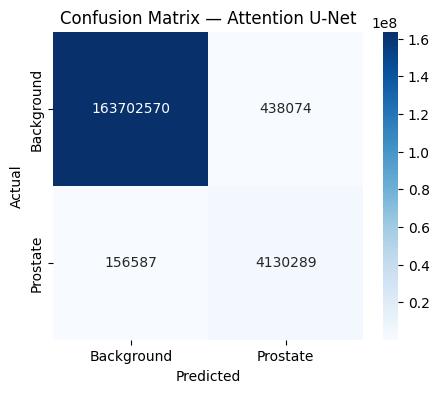

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

model.eval()
test_dice_scores, test_iou_scores, test_loss_total = [], [], 0
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        test_loss_total += (dice_loss(outputs, y) + ce_loss(outputs, y)).item()
        preds = torch.argmax(outputs, dim=1)

        pred_flat, target_flat = preds.view(-1), y.view(-1)
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum() - intersection

        dice = (2. * intersection + 1e-6) / (pred_flat.sum() + target_flat.sum() + 1e-6)
        iou = (intersection + 1e-6) / (union + 1e-6)
        test_dice_scores.append(dice.item())
        test_iou_scores.append(iou.item())

        all_preds.extend(pred_flat.cpu().numpy())
        all_targets.extend(target_flat.cpu().numpy())

mean_test_dice = np.mean(test_dice_scores)
mean_test_iou = np.mean(test_iou_scores)
mean_test_loss = test_loss_total / len(test_loader)

precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
acc = accuracy_score(all_targets, all_preds)

print(f"📊 Test Loss: {mean_test_loss:.4f}")
print(f"📊 Test Dice Coefficient: {mean_test_dice:.4f}")
print(f"📊 Test IoU: {mean_test_iou:.4f}")
print(f"📊 Test Accuracy: {acc:.4f}")
print(f"📊 Macro Precision: {precision:.4f} | Macro Recall: {recall:.4f} | Macro F1-Score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print("\n📊 Confusion Matrix (pixel-level, 0=Background, 1=Prostate):")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Background','Prostate'], yticklabels=['Background','Prostate'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Attention U-Net')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150); plt.show()

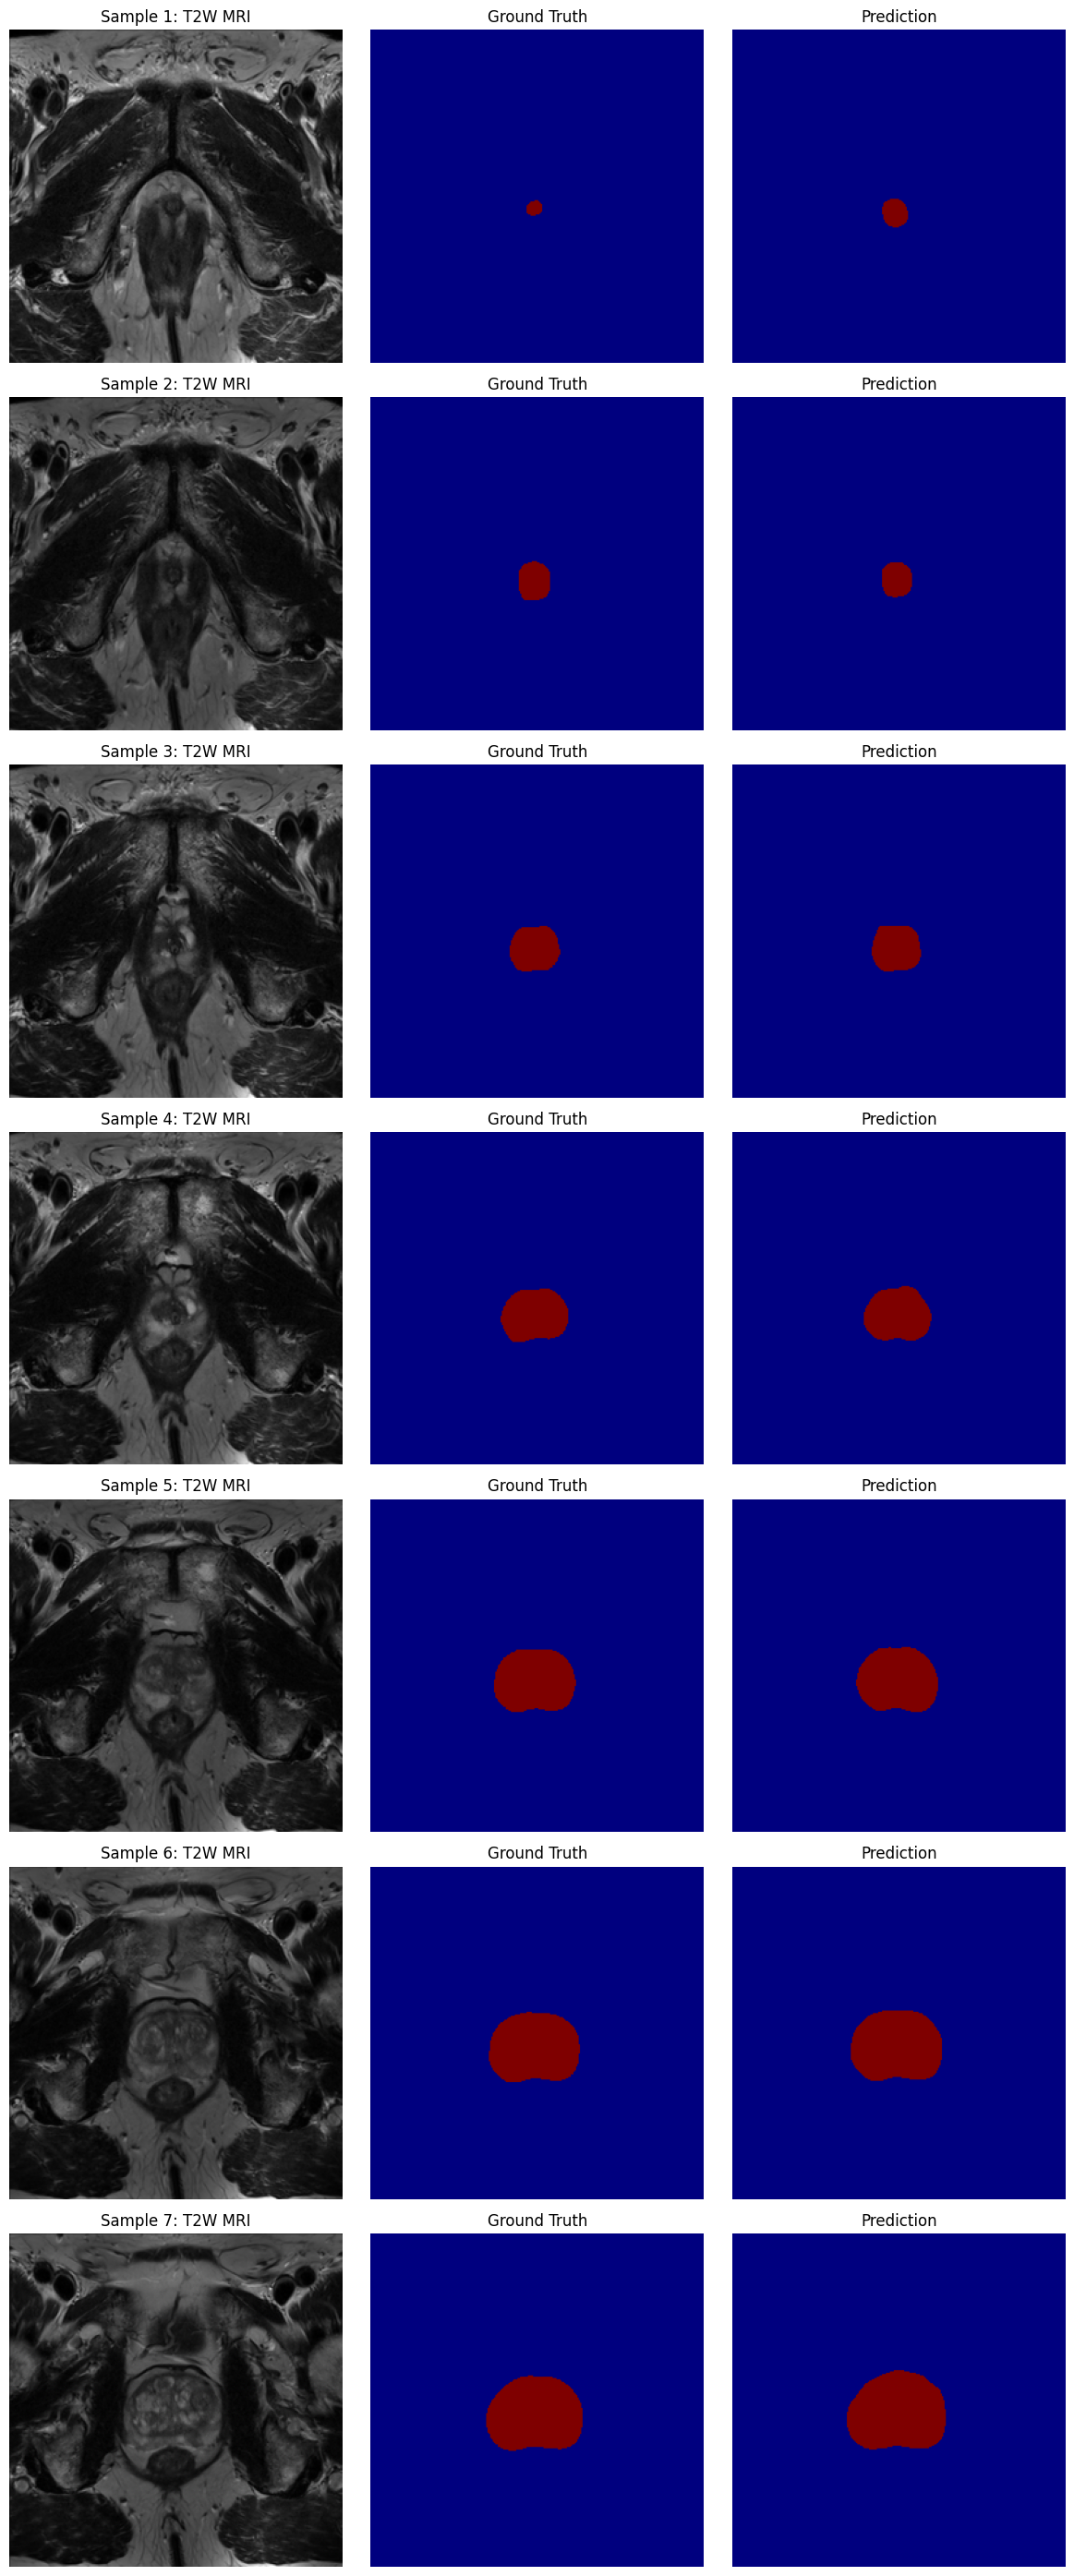

In [10]:
fig, axes = plt.subplots(7, 3, figsize=(12, 28))
images, masks = next(iter(test_loader))
with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

for i in range(7):
    axes[i,0].imshow(images[i].squeeze(), cmap='gray'); axes[i,0].set_title(f"Sample {i+1}: T2W MRI"); axes[i,0].axis('off')
    axes[i,1].imshow(masks[i], cmap='jet', vmin=0, vmax=1); axes[i,1].set_title("Ground Truth"); axes[i,1].axis('off')
    axes[i,2].imshow(preds[i], cmap='jet', vmin=0, vmax=1); axes[i,2].set_title("Prediction"); axes[i,2].axis('off')
plt.tight_layout(); plt.show()

In [14]:
from thop import profile

# Target primary device
primary_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dummy_input = torch.randn(1, 1, 256, 256).to(primary_device)

# Extract the underlying module if DataParallel is wrapping it, and move it to primary_device
target_model = model.module if isinstance(model, nn.DataParallel) else model
target_model.eval()
target_model.to(primary_device)

macs, params = profile(target_model, inputs=(dummy_input,), verbose=False)
gflops = (macs * 2) / 1e9  # Convert MACs to FLOPs then to GFLOPs

print(f"🔍 Total Parameters: {params:,}")
print(f"🔍 Computational Complexity: {gflops:.2f} GFLOPs")

🔍 Total Parameters: 7,854,174.0
🔍 Computational Complexity: 111.97 GFLOPs
